# Setup
- Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU"
- Install TerraTorch
    - You will have to restart the session after installing terratorch (it kinda looks like an error)

In [2]:
%pip install terratorch==1.1.1
%pip install gdown tensorboard zarr earthaccess folium

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import logging
from datetime import datetime, timedelta
from pathlib import Path

import earthaccess
import folium
import gdown
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import rasterio
import terratorch
from rasterio.features import rasterize
from rasterio.plot import show
from rasterio.transform import from_origin
from shapely.geometry import polygon
from torchgeo.datasets import RasterDataset, stack_samples
import torch
from torch.utils.data import DataLoader
from torchgeo.datasets import RasterDataset, BoundingBox, stack_samples
from torchgeo.datamodules import GeoDataModule
from torchgeo.datasets.utils import stack_samples, unbind_samples
from torchgeo.samplers import RandomGeoSampler, GridGeoSampler
import lightning.pytorch as pl
from lightning.pytorch.callbacks import LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import kornia.augmentation as K

import warnings
from IPython.core.debugger import set_trace

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.ERROR)
logging.getLogger("rasterio").setLevel(logging.ERROR)

# Download the Hail and Wind Damage Swath (HWDS) Event Database

A 21-year climatology (2000-2020) of hail and wind damage swaths derived from daily MODIS imagery and storm reports.

Hail and wind damage swaths (HWDSs) frequently occur during the warmest months of the growing season throughout the Midwest and Great Plains but are not yet officially documented or tracked like other severe weather impacts (e.g., tornadoes and derechos). The creation of a 21-year HWDS event database using archived daily storm reports and daily true color satellite imagery. Once the database was completed and underwent quality checks, the research team identified spatial and temporal trends from the confirmed swaths.

For more information check out the [github repo](https://github.com/jrbell1/hwds_db).

In [4]:
hwds_google_drive_id = '1TC7JsbrSGTpS0CEvEbGp9TqtxDjAdLBG'
drive_url = f'https://drive.google.com/uc?id={hwds_google_drive_id}'
filename = '25_hwds_shapefile'

if not Path(f'{filename}.zip').exists():
  gdown.download(drive_url)
  !unzip 25_hwds_shapefile.zip

shp_path = Path(filename) / 'hls_hwds_polygons.shp'

# Load the data using geopandas

In [5]:
gdf = gpd.read_file(shp_path)

2019-05-17


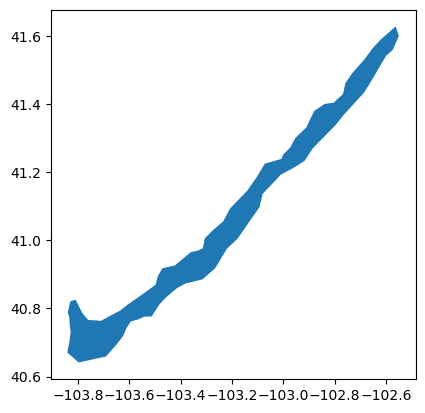

In [6]:
swath_id = '97'
swath_gdf = gdf[gdf['swathID'] == swath_id]
swath = swath_gdf.iloc[0]

best_post_date = datetime(year=2019, month=5, day=24) # Update this for different swaths

swath_gdf.plot()
print(swath['swathDate'])

## Turn label geometry into raster

For training we are going to turn the damage swath geometry into a geotiff. To accomplish this we are going to use 
[rasterio](https://github.com/rasterio/rasterio) which is a library for this. 


Before we generate our swath tif we are also going to setup some directories for where our data will go.

In [7]:
data_path = Path.cwd() / 'data' / f'swath_{swath_id}'
hls_path = data_path / 'HLS'
label_path = data_path / 'LABEL'

for data_path in (hls_path, label_path):
    data_path.mkdir(parents=True, exist_ok=True) 

In [8]:
utm_crs = gdf.estimate_utm_crs()
gdf_crs = gdf.to_crs(utm_crs)

swath_crs_gdf = gdf_crs[gdf_crs['swathID'] == swath_id]

In [9]:
pixel_size_meters = 30
padding_meters = 1000

def add_padding_to_bounds(bounds):
    minx, miny, maxx, maxy = bounds
    minx -= padding_meters
    miny -= padding_meters
    maxx += padding_meters
    maxy += padding_meters
    
    return minx, miny, maxx, maxy

def rasterize_swath(selected_swath_gdf):
    selected = selected_swath_gdf.iloc[0]
    geom = selected.geometry
    minx, miny, maxx, maxy = add_padding_to_bounds(geom.bounds)
    
    width = int(np.ceil((maxx - minx) / pixel_size_meters))
    height = int(np.ceil((maxy - miny) / pixel_size_meters))

    transform = from_origin(minx, maxy, pixel_size_meters, pixel_size_meters)

    rasterized = rasterize(
        [(geom, 1)],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype='uint8'
    )

    out_path = label_path / f'swathID_{swath_id}.tif'

    with rasterio.open(
        out_path, 'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype='uint8',
        crs=selected_swath_gdf.crs,
        transform=transform
    ) as dst:
        dst.write(rasterized, 1)
        dst.update_tags(polygon_id=str(swath_id))
    
    return out_path

label_raster = rasterize_swath(swath_crs_gdf)

## Visualize Label Raster

Talk about the raster a bit

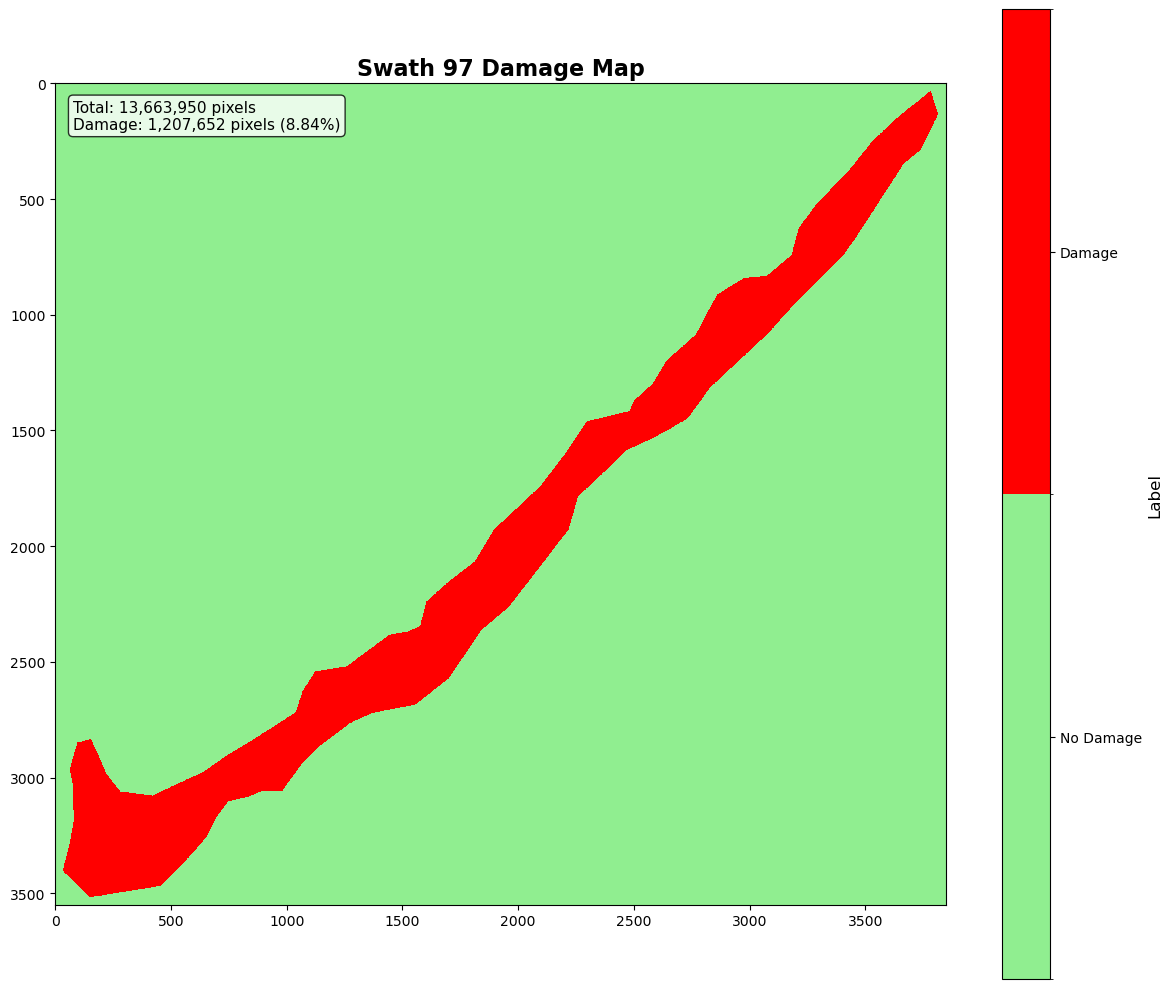

In [10]:
with rasterio.open(label_raster) as src:
    data = src.read(1)
    
    colors = ['lightgreen', 'red']  # 0=no damage, 1=damage
    cmap = mcolors.ListedColormap(colors)
    bounds = [-0.5, 0.5, 1.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(data, cmap=cmap, norm=norm, interpolation='nearest')
    ax.set_title(f'Swath {swath_id} Damage Map', fontsize=16, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1])
    cbar.set_label('Label', fontsize=12)
    cbar.ax.set_yticklabels(['No Damage', 'Damage'])
    
    total_pixels = data.size
    damage_pixels = np.sum(data == 1)
    damage_pct = (damage_pixels / total_pixels) * 100
    
    textstr = f'Total: {total_pixels:,} pixels\nDamage: {damage_pixels:,} pixels ({damage_pct:.2f}%)'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, 
            fontsize=11, verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()

# Find hls data based on polygon

To search for HLS data we will be using [earthaccess](https://earthaccess.readthedocs.io/en/latest/user-reference/api/api/#earthaccess.api.search_data). For HLS there are 2 collections one for Sentinel 2 data ('HLSS30') and one for Landsat data ('HLSL30'). We will only be using the Sentinel 2 since [terramind](https://terrastackai.github.io/terratorch/stable/guide/terramind/#model-versions) has only been trained on S2 data. 

We are searching for data over the damage polygon after the damage event has happened.

In [11]:
earthaccess.login()

INFO:earthaccess.auth:You're now authenticated with NASA Earthdata Login


In [12]:
geometry = polygon.orient(swath.geometry, sign=1.0)

results = earthaccess.search_data(
    short_name='HLSS30',
    polygon=list(geometry.exterior.coords),
    temporal=(best_post_date, best_post_date + timedelta(days=1))
)

INFO:earthaccess.api:Granules found: 7


## Visualizing Results 

To visualize our results we can compare our damage swath to the extents of the results we got from [earthaccess](https://earthaccess.readthedocs.io/en/latest/user-reference/api/api/). 
For a more in depth search [earthdata search](https://search.earthdata.nasa.gov/search?q=HLSS30) or download and open the hls data inspect it in GIS software. 

In [13]:
geotiff_list = results

def plot_geotiff_extents(results_list, selected_gdf):
    all_lats, all_lons = [], []
    
    m = folium.Map(tiles="OpenStreetMap")
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, metadata in enumerate(results_list):
        points = metadata['umm']['SpatialExtent']['HorizontalSpatialDomain']['Geometry']['GPolygons'][0]['Boundary']['Points']
        
        footprint_coords = []
        for point in points:
            lat, lon = point['Latitude'], point['Longitude']
            footprint_coords.append((lat, lon))
            all_lats.append(lat)
            all_lons.append(lon)
        
        tile_color = colors[i % len(colors)]

        folium.Polygon(
            locations=footprint_coords,
            tooltip=f"HLS Tile: {metadata['umm']['GranuleUR']}",
            color=tile_color,
            weight=3,
            fill=True,
            fill_color=tile_color,
            fill_opacity=0.3
        ).add_to(m)
        
    folium.GeoJson(
        selected_gdf.to_json(),
        style_function=lambda x: {
            'fillColor': '#8c564b', 
            'color': '#8c564b',
            'weight': 4,
            'fillOpacity': 0.5
        },
        tooltip=folium.features.GeoJsonTooltip(fields=['swathID', 'swathDate'], aliases=['Swath ID:', 'Date:'], localize=True)
    ).add_to(m)
    
    if all_lats and all_lons:
        map_bounds = [[min(all_lats), min(all_lons)], [max(all_lats), max(all_lons)]]
        m.fit_bounds(map_bounds)

    folium.LayerControl().add_to(m)
    
    return m

In [14]:
final_map = plot_geotiff_extents(results, swath_gdf)
final_map

## Download Data

For training we are going to focus on one event at a time. So data will organized by event and then by data type `HLS` or `LABEL`.

In [15]:
files = earthaccess.download(
    results,
    local_path=hls_path
)

INFO:earthaccess.store: Getting 7 granules, approx download size: 1.46 GB


QUEUEING TASKS | :   0%|          | 0/126 [00:00<?, ?it/s]

INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B11.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B10.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B01.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.Fmask.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B03.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.VZA.tif already downloaded


PROCESSING TASKS | :   0%|          | 0/126 [00:00<?, ?it/s]

INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B05.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B07.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B06.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B12.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B02.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B09.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.VAA.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B8A.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B04.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B08.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.SZA.tif already downloaded
INFO:earth

COLLECTING RESULTS | :   0%|          | 0/126 [00:00<?, ?it/s]

## Setup Datasets 

TODO:
- Talk about datasets
- Link out to torchgeo docs

In [29]:
from typing import Any


class HLSDataset(RasterDataset):
    """
    HLS dataset using TorchGeo's RasterDataset base class.
    
    Example file name:
        HLS.S30.T13TFF.2019144T173909.v2.0.B08.tif

    Bands:
        B01 ->  COASTAL
        B02 ->  BLUE
        B03 ->  GREEN
        B04 ->  RED
        B05 ->  REDEDGE1
        B06 ->  REDEDGE2
        B07 ->  REDEDGE3
        B08 ->  NIR
        B8A ->  NIR08
        B09 ->  NIR09
        B11 ->  SWIR16
        B12 ->  SWIR22
    """
    
    filename_glob = "HLS.*.tif"
    filename_regex = r"^HLS\.(?P<sensor>[SL])30\.(?P<tile>T\w+)\.(?P<date>\d+T\d+)\.v\d+\.\d+\.(?P<band>B\w+|SZA|SAA|VZA|VAA)\.tif$"
    date_format = '%Y%d%mT%H%M%S'
    
    separate_files = True
    is_image = True
    
    all_bands = ("B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12")
    rgb_bands = ('B04', 'B03', 'B02')
    
    def plot(
            self, 
            sample: dict[str, Any],
            show_titles: bool = True,
            suptitle: str | None = None,
        ):
        rgb_indices = []
        for band in self.rgb_bands:
            rgb_indices.append(self.bands.index(band))

        image = sample['image'][rgb_indices].permute(1, 2, 0)
        # DN = 10000 * REFLECTANCE
        # https://docs.sentinel-hub.com/api/latest/data/sentinel-2-l2a/
        image = torch.clamp(image / 10000, min=0, max=1)

        fig, ax = plt.subplots(1, 1, figsize=(4, 4))

        ax.imshow(image)
        ax.axis('off')

        if show_titles:
            ax.set_title('Image')

        if suptitle is not None:
            plt.suptitle(suptitle)

        return fig


class LabelDataset(RasterDataset):
    filename_glob = "swathID_*.tif"
    is_image = False

    def plot(self, sample):
        mask = sample['mask']
        
        if mask.dim() == 3:  # (C, H, W)
            mask = mask[0]
        elif mask.dim() == 4:  # (B, C, H, W)
            mask = mask[0, 0]
        
        mask = mask.numpy()
        
        fig, ax = plt.subplots()
        ax.imshow(mask, cmap='viridis')
        ax.axis('off')

        ax.set_title('Damage Label')
        
        return fig


## Data Normilization

Talk about how and why we normilize data when training AI models
Link to docs about this

In [30]:
hls_dataset = HLSDataset(
    paths=hls_path,
    bands=('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 
               'B07', 'B08', 'B8A', 'B09', 'B11', 'B12')
)

def calculate_band_stats(band_tifs: list[Path]) -> tuple[float, float]:
    count, mean, M2 = 0, 0, 0
    
    for band_tif in band_tifs:
        with rasterio.open(band_tif) as src:
            band_data = src.read(1).flatten()
            
            batch_count = len(band_data)
            batch_mean = np.mean(band_data)
            batch_var = np.var(band_data)
            
            # Parallel variance algorithm: https://jonisalonen.com/2013/deriving-welfords-method-for-computing-variance/
            delta = batch_mean - mean
            mean = (count * mean + batch_count * batch_mean) / (count + batch_count)
            M2 = M2 + batch_var * batch_count + delta**2 * count * batch_count / (count + batch_count)
            count += batch_count
    
    variance = M2 / count
    std = np.sqrt(variance)
    
    return mean, std


HLS_MEAN, HLS_STD = [], []
print('Band, Mean, Std')
for band in hls_dataset.bands:
    mean, std = calculate_band_stats([f for f in hls_dataset.files if f'{band}.tif' in f])
    print(band, f'{mean:.2f}', f'{std:.2f}')
    HLS_MEAN.append(mean)
    HLS_STD.append(std)

Band, Mean, Std
B01 565.89 1137.23
B02 674.88 1145.97
B03 986.92 1176.77
B04 1152.91 1217.22
B05 1461.42 1229.23
B06 1998.67 1280.78
B07 2211.27 1327.95
B08 2310.64 1347.11
B8A 2446.05 1352.69
B09 1153.80 1119.03
B11 3112.19 1412.86
B12 2223.23 1309.65


## Setup DataLoader

- Talk about samplers
- Talk about data loaders

In [40]:
patch_size = 224
batch_size = 1

label_dataset = LabelDataset(paths=label_path)
dataset = label_dataset & hls_dataset

train_sampler = RandomGeoSampler(
    dataset,
    size=patch_size,
    length=10,
)

dataloader = DataLoader(
    dataset,
    sampler=train_sampler,
    batch_size=2,
    collate_fn=stack_samples,
)

5
Batch: dict_keys(['crs', 'bounds', 'mask', 'image']), Image Shape: torch.Size([2, 12, 224, 224])
Single Sample: dict_keys(['crs', 'bounds', 'mask', 'image']), Image Shape: torch.Size([12, 224, 224])


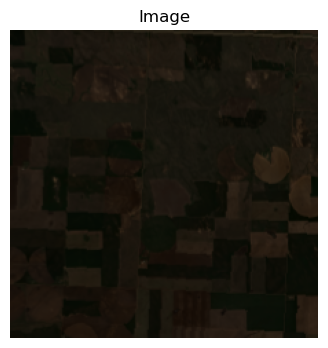

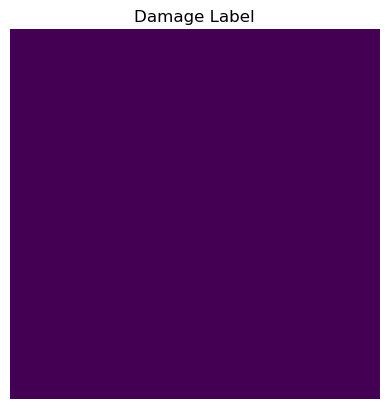

In [41]:
print(len(dataloader))

for batch in dataloader:
    print(f"Batch: {batch.keys()}, Image Shape: {batch['image'].shape}")

    sample = unbind_samples(batch)[0]
    print(f"Single Sample: {sample.keys()}, Image Shape: {sample['image'].shape}")

    hls_dataset.plot(sample)
    label_dataset.plot(sample)
    break

{'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 14N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32614"]]'), 'bounds': BoundingBox(minx=133079.1845828159, maxx=139799.1845828159, miny=4593411.558418287, maxy=4600131.558418287, mint=1555292349.0, maxt=1555292349.999999), 'mask': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ...,

ValueError: If you are using a dictionary as input, the data_keys should be None.

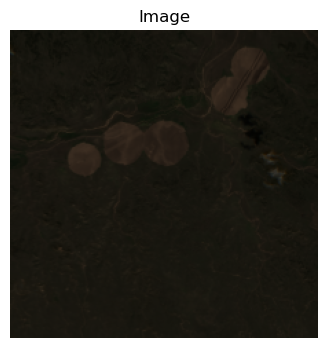

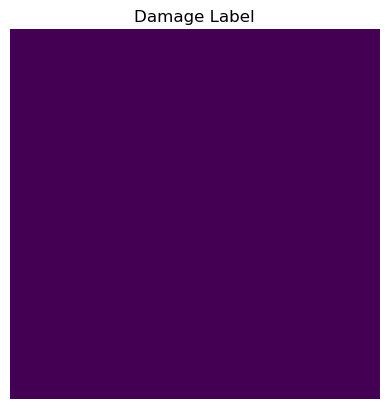

In [ ]:
transform = K.AugmentationSequential(
    K.Normalize(HLS_MEAN, HLS_STD),
    K.Resize((patch_size, patch_size)), 
    K.RandomVerticalFlip(p=0.5),
    K.RandomHorizontalFlip(p=0.5),
    data_keys=['image', 'mask'],
    keepdim=True,
)

for batch in dataloader:
    sample = unbind_samples(batch)[0]
    hls_dataset.plot(sample)
    label_dataset.plot(sample)

    transformed_batch = transform(batch)
    transformed_sample = unbind_samples(transformed_batch)[0]

    hls_dataset.plot(transformed_sample)
    label_dataset.plot(transformed_sample)

    break

## Setup DataModule 

TODO:
- Talk about datamodule
- Talk about transforms
- Talk about collate function
- Link out to docs (lightning, torchgeo)

In [33]:
class HLSDataModule(GeoDataModule):  
    def __init__(
        self,
        hls_path: str,
        label_path: str,
        batch_size: int = 8,
        patch_size: int = 224,
        train_length: int = 100,
        val_length: int = 20,
        num_workers: int = 4,
    ):
        super().__init__(HLSDataset)
        
        self.hls_path = hls_path
        self.label_path = label_path
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.train_length = train_length
        self.val_length = val_length
        self.num_workers = num_workers
        
        self.train_aug = K.AugmentationSequential(
            K.Normalize(HLS_MEAN, HLS_STD),
            K.Resize((self.patch_size, self.patch_size)), 
            K.RandomVerticalFlip(p=0.5),
            K.RandomHorizontalFlip(p=0.5),
            data_keys=['image', 'mask'],
            keepdim=True,
        )
        
        self.val_aug = K.AugmentationSequential(
            K.Normalize(HLS_MEAN, HLS_STD),
            K.Resize((self.patch_size, self.patch_size)),
            data_keys=['image', 'mask'],
            keepdim=True,
        )
        
        self.test_aug = self.val_aug
        
    def setup(self, stage=None):
        self.hls_dataset = HLSDataset(
            paths=self.hls_path,
            bands=('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 
                   'B07', 'B08', 'B8A', 'B09', 'B11', 'B12')
        )
        
        self.label_dataset = LabelDataset(paths=self.label_path)
        self.dataset = self.label_dataset & self.hls_dataset
        
        bounds = self.dataset.bounds
        split_x = bounds.minx + 0.8 * (bounds.maxx - bounds.minx)
        
        self.train_roi = BoundingBox(
            minx=bounds.minx,
            maxx=split_x,
            miny=bounds.miny,
            maxy=bounds.maxy,
            mint=bounds.mint,
            maxt=bounds.maxt,
        )
        self.val_roi = BoundingBox(
            minx=split_x,
            maxx=bounds.maxx,
            miny=bounds.miny,
            maxy=bounds.maxy,
            mint=bounds.mint,
            maxt=bounds.maxt,
        )

        self.train_sampler = GridGeoSampler(
            self.dataset,
            size=self.patch_size,
            stride=self.patch_size,
            roi=self.train_roi,
        )
        self.val_sampler = GridGeoSampler(
            self.dataset,
            size=self.patch_size,
            stride=self.patch_size,
            roi=self.val_roi,
        )

        if stage in ['fit', 'validate']:
            self.train_dataset = self.train_dataloader()
            self.val_dataset = self.val_dataloader()

    def train_collate_fn(self, batch):
        stacked = stack_samples(batch)
        return {
            'image': {'S2L2A': stacked['image']},  # Keep nested structure
            'mask': stacked['mask'],
            'crs': stacked['crs'],
            'bounds': stacked['bounds']
        }

    def val_collate_fn(self, batch):
        stacked = stack_samples(batch)
        return {
            'image': {'S2L2A': stacked['image']},  # Keep nested structure
            'mask': stacked['mask'],
            'crs': stacked['crs'],
            'bounds': stacked['bounds']
        }

    def train_dataloader(self):
        return DataLoader(
            self.dataset,
            sampler=self.train_sampler,
            batch_size=self.batch_size,
            collate_fn=self.train_collate_fn,
            num_workers=self.num_workers,
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.dataset,
            sampler=self.val_sampler,
            batch_size=self.batch_size,
            collate_fn=self.val_collate_fn,
            num_workers=self.num_workers,
        )

    def on_after_batch_transfer(self, batch, dataloader_idx):
        if self.trainer.training:
            aug = self.train_aug
        elif self.trainer.validating or self.trainer.sanity_checking:
            aug = self.val_aug
        else:
            aug = self.test_aug
        
        image = batch['image']['S2L2A']
        mask = batch['mask']
        
        image, mask = aug(image, mask)
        
        batch['image']['S2L2A'] = image
        batch['mask'] = mask
        
        return batch
        
    def plot(self, sample, split='val'):
        def plot_binary_mask(ax, mask_data, title, fig):
            if mask_data.dim() == 3:  # (C, H, W)
                mask_data = mask_data[0]
            elif mask_data.dim() == 4:  # (B, C, H, W)
                mask_data = mask_data[0, 0]
                
            mask_np = mask_data.numpy()
            
            colors = ['lightgreen', 'red']  # 0=no damage, 1=damage
            cmap = ListedColormap(colors)
            bounds = [-0.5, 0.5, 1.5]
            norm = BoundaryNorm(bounds, cmap.N)
            
            im = ax.imshow(mask_np, cmap=cmap, norm=norm, interpolation='nearest')
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.axis('off')
            
            cbar = fig.colorbar(im, ax=ax, ticks=[0, 1], fraction=0.046)
            cbar.set_label(title, fontsize=12)
            cbar.ax.set_yticklabels(['No Damage', 'Damage'])
        
        if 'image' in sample and isinstance(sample['image'], dict):
            standard_sample = {
                'image': sample['image']['S2L2A'],
                'mask': sample['mask']
            }
        else:
            standard_sample = sample
        
        has_prediction = 'prediction' in sample
        num_plots = 3 if has_prediction else 2
        
        fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))
        
        hls_fig = self.hls_dataset.plot(standard_sample)
        hls_ax = hls_fig.axes[0]
        for image in hls_ax.get_images():
            axes[0].imshow(image.get_array())
        axes[0].set_title('HLS RGB Image', fontsize=14, fontweight='bold')
        axes[0].axis('off')
        plt.close(hls_fig)
        
        plot_binary_mask(axes[1], standard_sample['mask'], 'Label', fig)
        
        if has_prediction:
            plot_binary_mask(axes[2], sample['prediction'], 'Prediction', fig)
        
        plt.tight_layout()
        return fig

In [34]:
datamodule = HLSDataModule(
    hls_path=hls_path,
    label_path=label_path,
    batch_size=8
)

datamodule.setup()

Converting HLSDataset CRS from EPSG:32613 to EPSG:32614


In [35]:
dataloader = datamodule.train_dataloader()
loader_iter = iter(dataloader)
print(len(loader_iter))

697


tensor(1072.8857)


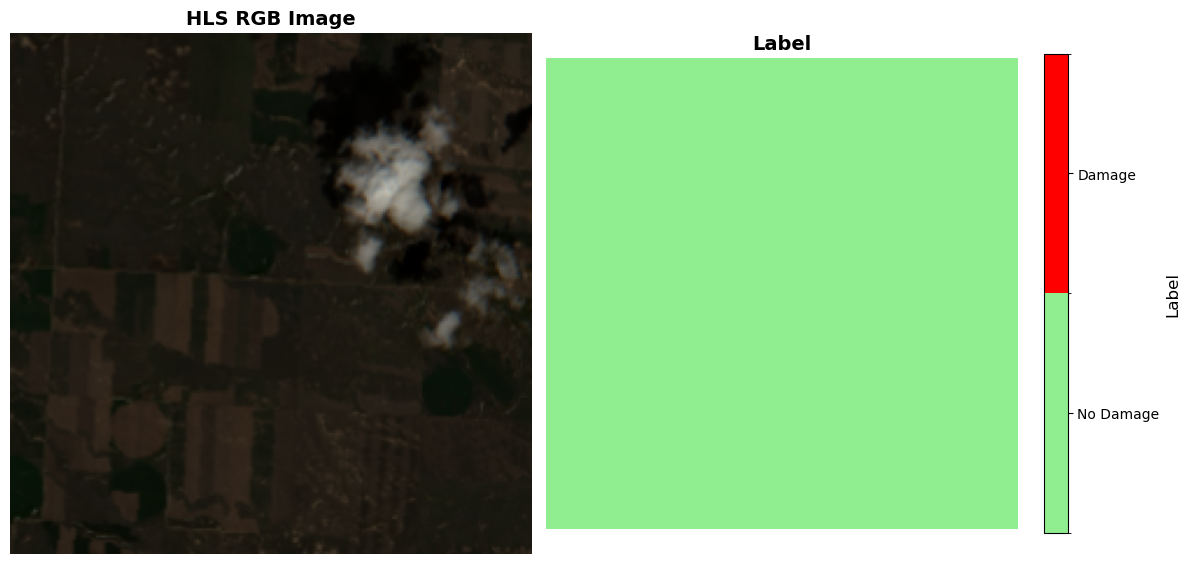

In [36]:
batch = next(loader_iter)
batch_size = batch['image']['S2L2A'].shape[0]

sample = {
    'image': {'S2L2A': batch['image']['S2L2A'][0]},
    'mask': batch['mask'][0]
}
print(sample['image']['S2L2A'].std())

# Create temporary figure from datamodule.plot()
temp_fig = datamodule.plot(sample)

plt.tight_layout()
plt.show()

## Terratorch

TODO: 
- talk about terratorch
- talk about/link to info about loss/optimizer/learning-rate 

## Terratorch

TODO: 
- talk about/link to info about loss/optimizer/learning-rate 
- talk about lightning tasks
- link to other tutorials

In [37]:
MODALITIES = ['S2L2A']

model = terratorch.tasks.SemanticSegmentationTask(
  model_factory='EncoderDecoderFactory',
  model_args={
      'backbone': 'terramind_v1_base',
      'backbone_pretrained': True,
      'backbone_modalities': MODALITIES,
      'necks': [
          {'name': 'SelectIndices', 'indices': [2, 5, 8, 11]},
          {'name': 'ReshapeTokensToImage', 'remove_cls_token': False},
          {'name': 'LearnedInterpolateToPyramidal'}
      ],
      'decoder': 'UNetDecoder',
      'decoder_channels': [512, 256, 128, 64],
      'head_dropout': 0.1,
      'num_classes': 2,
  },
  loss='dice',
  optimizer='AdamW',
  lr=1e-5,
  ignore_index=-1,
  freeze_backbone=False,
  freeze_decoder=False,
  plot_on_val=True,
  class_names=['no-damage', 'damage'],
)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"


## Pytorch Lightning

- Talk more about pytorch lightning
- Link to docs

In [26]:

# TensorBoard logger
tb_logger = TensorBoardLogger(
  save_dir='output/terramind_base_hwds/',
  name='tensorboard_logs',
)

# Callbacks
checkpoint_callback = pl.callbacks.ModelCheckpoint(
  dirpath='output/terramind_base_hwds/checkpoints/',
  filename='best-epoch{epoch:02d}-mIoU{val/mIoU:.4f}',
  monitor='val/mIoU',
  mode='max',
  save_top_k=1,
  save_last=True,
  save_weights_only=False,
  auto_insert_metric_name=False,
)

lr_monitor = LearningRateMonitor(logging_interval='step')

trainer = pl.Trainer(
  accelerator='auto',
  strategy='auto',
  num_nodes=1,
  logger=tb_logger,
  max_epochs=3,
  log_every_n_steps=5,
  callbacks=[
      checkpoint_callback,
      lr_monitor,
      pl.callbacks.RichProgressBar()
  ],
  default_root_dir='output/terramind_base_hwds/',
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


## Tensorboard

- talk about tensor board
- talk about plotting on validation
- link to docs

In [29]:
%load_ext tensorboard
%tensorboard --logdir output

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 8658), started 0:36:55 ago. (Use '!kill 8658' to kill it.)

## Fine turning

- talk about putting it all together

In [28]:
trainer.fit(model, datamodule=datamodule)

/home/wbhorn/miniforge3/envs/torchgeo/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/wbhorn/repositories/tools/terramind-docs/severe-weather/notebooks/output/terramind_base_hwds/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Converting HLSDataset CRS from EPSG:32613 to EPSG:32614


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  102 M │ train │
│ 1 │ criterion     │ DiceLoss         │      0 │ train │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │
└───┴───────────────┴──────────────────┴────────┴───────┘

Trainable params: 102 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 M                                                                                                
Total estimated model params size (MB): 411                                                                        
Modules in train mode: 288                                                                                         
Modules in eval mode: 0

Output()

/home/wbhorn/miniforge3/envs/torchgeo/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: 
UserWarning: The ``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which may 
lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

/home/wbhorn/miniforge3/envs/torchgeo/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: 
UserWarning: The ``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which may 
lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

/home/wbhorn/miniforge3/envs/torchgeo/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: 
UserWarning: The ``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which may 
lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

INFO: `Trainer.fit` stopped: `max_epochs=3` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


## Glossary

TODO: Add a glossary with a bunch of links